# Análisis exploratorio de los datos estructurados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### Carga de datos

In [3]:
df_agri = pd.read_csv('datos/produccion_agricola.csv')
df_gana = pd.read_csv('datos/produccion_ganadera.csv')
df_precios = pd.read_csv('datos/precios_mercado_limpios.csv')
df_img = pd.read_csv('datos/imagenes_metadata_limpias.csv')

In [4]:
df_agri.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [5]:
df_gana.head()

,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346
4,Argentina,2011,caprino,2045715,345732,454558689,284966,0.139,0.1690


In [6]:
df_precios.head()

,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes,anio_precio,mes_precio,dia_precio
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42,2021,1,1
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86,2021,1,1
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83,2021,1,1
3,2021-01-01,Brasil,Maíz,212.91,195579,subiendo,Oriente Medio,200.25,243.04,2021,1,1
4,2021-01-01,Brasil,Leche,356.41,136137,subiendo,UE,348.39,390.03,2021,1,1


In [7]:
df_img.head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


### Análisis agricola y satelite

#### 1. Fertilizantes vs Rendimiento

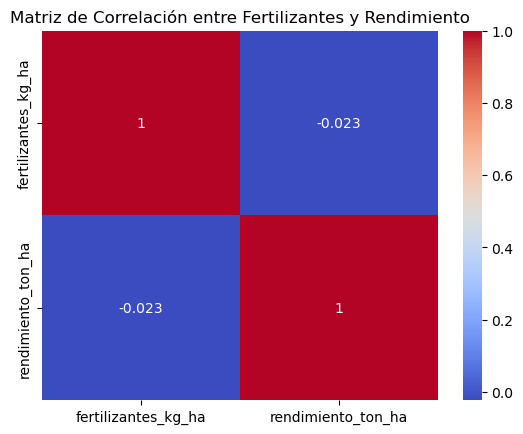

In [8]:
#Matriz de correlación para kg de fertilizante y rendimiento
correlation_matrix = df_agri[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

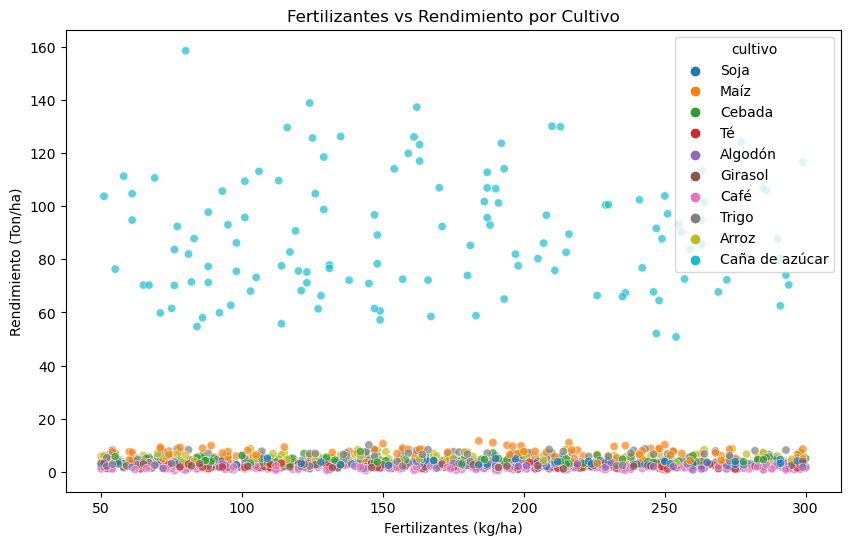

In [9]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot(data=df_agri, x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', alpha=0.7)
plt.title('Fertilizantes vs Rendimiento por Cultivo')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (Ton/ha)')
plt.show()

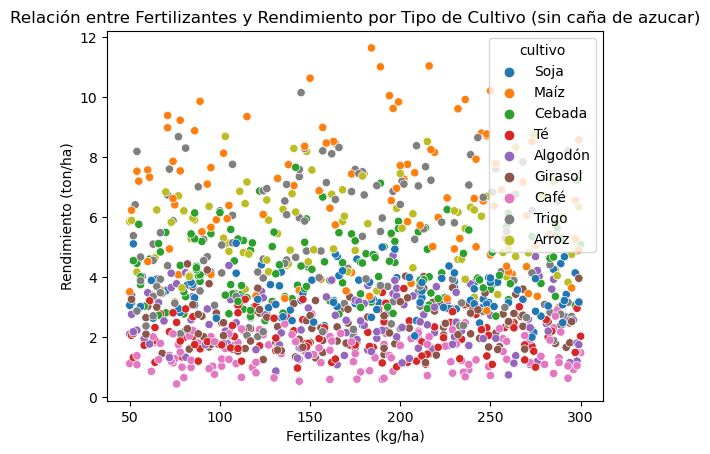

In [10]:
#Grafico de dispersión para kg de fertilizante y rendimiento quitando el cultivo de caña de azucar
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
sns.scatterplot(x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', data=df_sin_cana)
plt.title('Relación entre Fertilizantes y Rendimiento por Tipo de Cultivo (sin caña de azucar)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

#### 2. Superficie vs producción

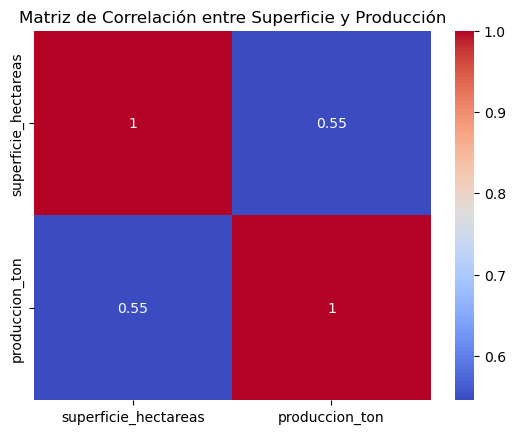

In [11]:
#Matriz de correlación para superficie y produccion
correlation_matrix = df_agri[['superficie_hectareas', 'produccion_ton']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Superficie y Producción')
plt.show()

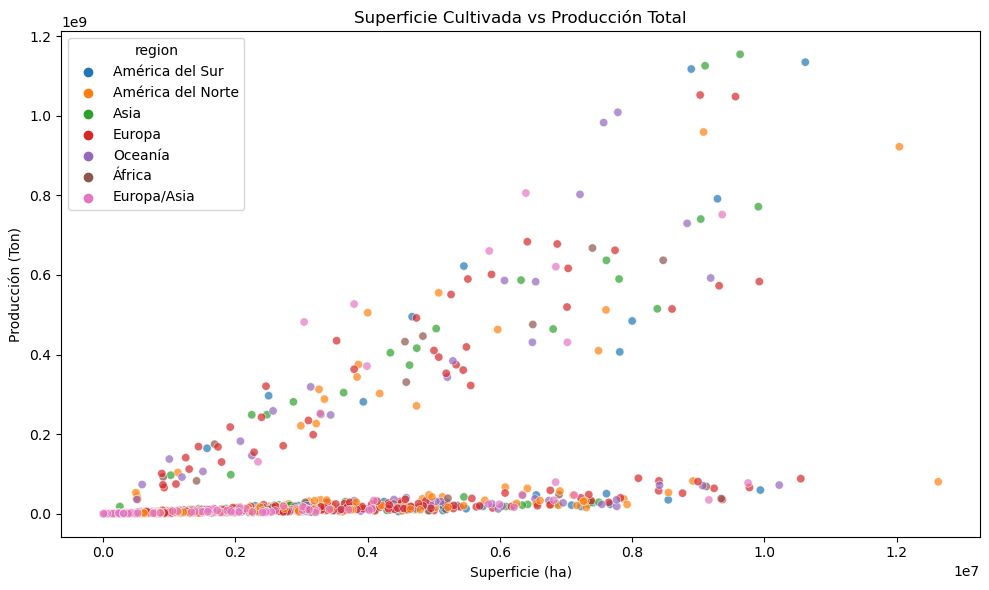

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agri, x='superficie_hectareas', y='produccion_ton', hue='region', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

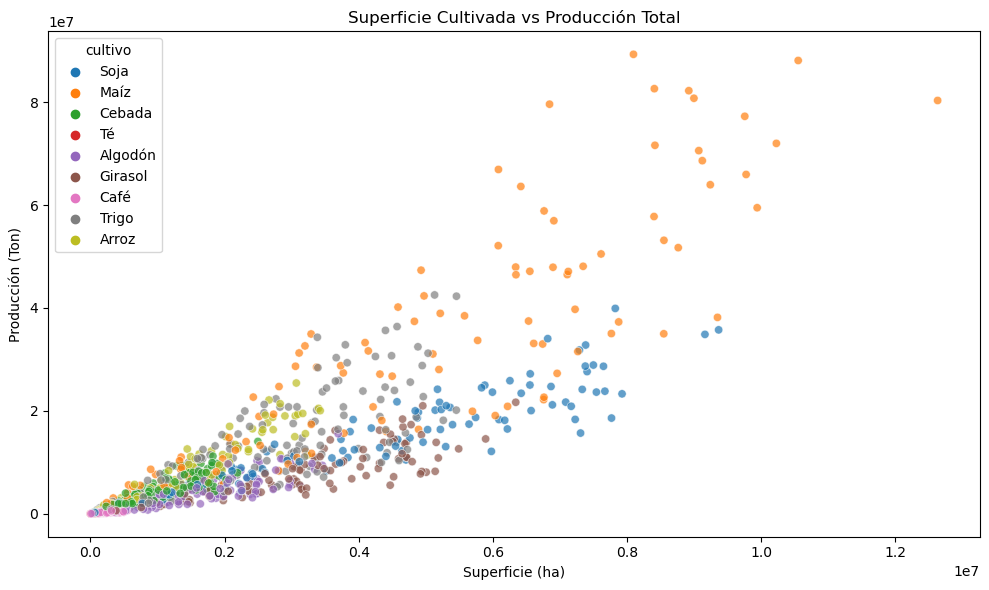

In [13]:
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sin_cana, x='superficie_hectareas', y='produccion_ton', hue='cultivo', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

#### 3. Relación agua vs rendimiento

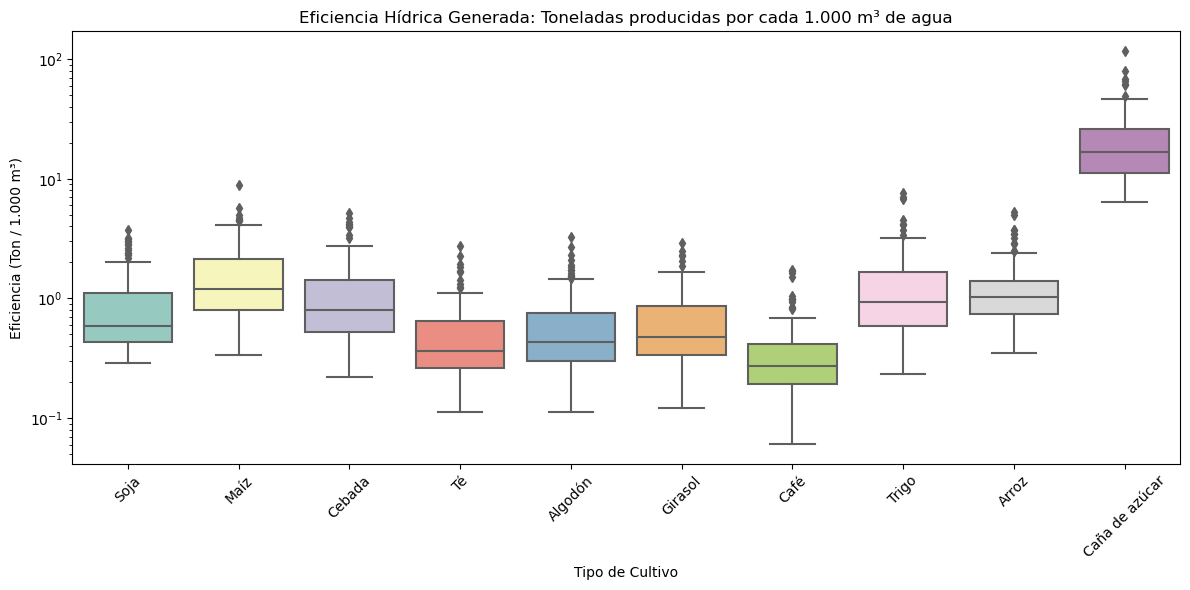

In [14]:
# Calculamos: ¿Cuántas toneladas produce con 1000 m3 de agua?
df_agri['eficiencia_hidrica'] = df_agri['rendimiento_ton_ha'] / (df_agri['agua_riego_m3_ha'] / 1000)

plt.figure(figsize=(12, 6))
# Usamos un boxplot para ver la distribución completa y la mediana por cultivo
sns.boxplot(
    data=df_agri, 
    x='cultivo', 
    y='eficiencia_hidrica', 
    palette='Set3'
)
plt.title('Eficiencia Hídrica Generada: Toneladas producidas por cada 1.000 m³ de agua')
plt.ylabel('Eficiencia (Ton / 1.000 m³)')
plt.xlabel('Tipo de Cultivo')
plt.xticks(rotation=45)
# Escala logarítmica si hay cultivos con eficiencias extremadamente altas/bajas
plt.yscale('log') 
plt.tight_layout()
plt.show()

#### 4. Relaciones satelitales

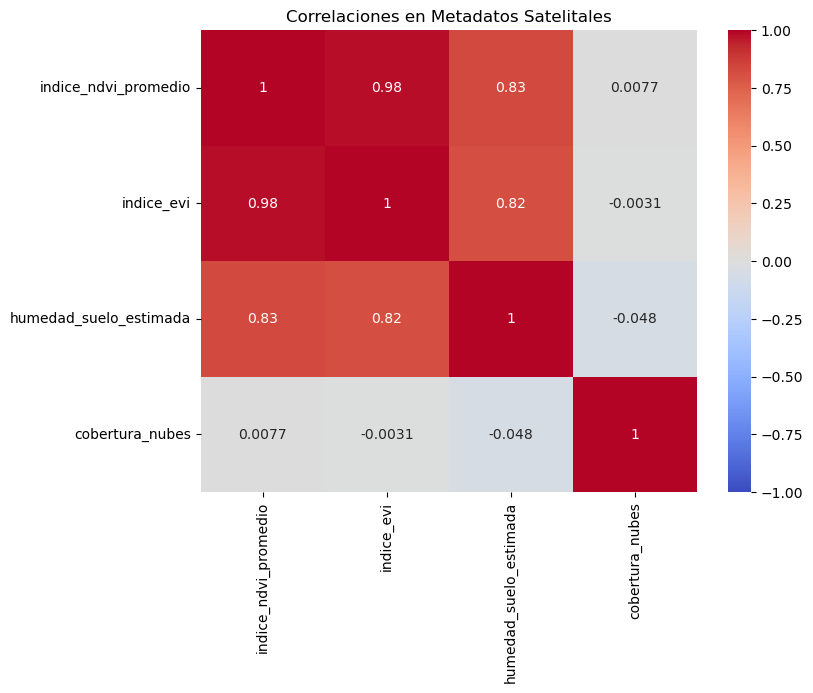

In [15]:
# Matriz Satelital
plt.figure(figsize=(8, 6))
cols_img = ['indice_ndvi_promedio', 'indice_evi', 'humedad_suelo_estimada', 'cobertura_nubes']
sns.heatmap(df_img[cols_img].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlaciones en Metadatos Satelitales')
plt.show()

### Análisis temporales 

#### 1. Tendencia de producción global por cultivo y pais

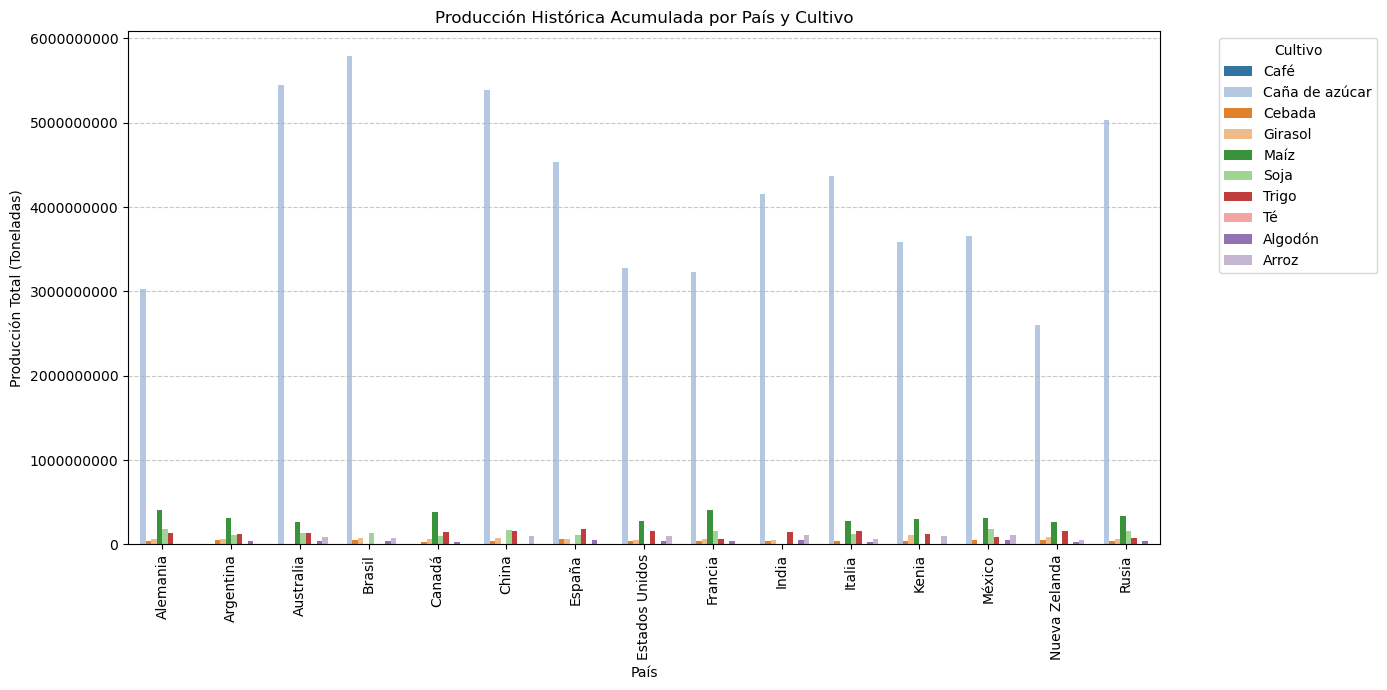

In [16]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo[prod_pais_cultivo['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

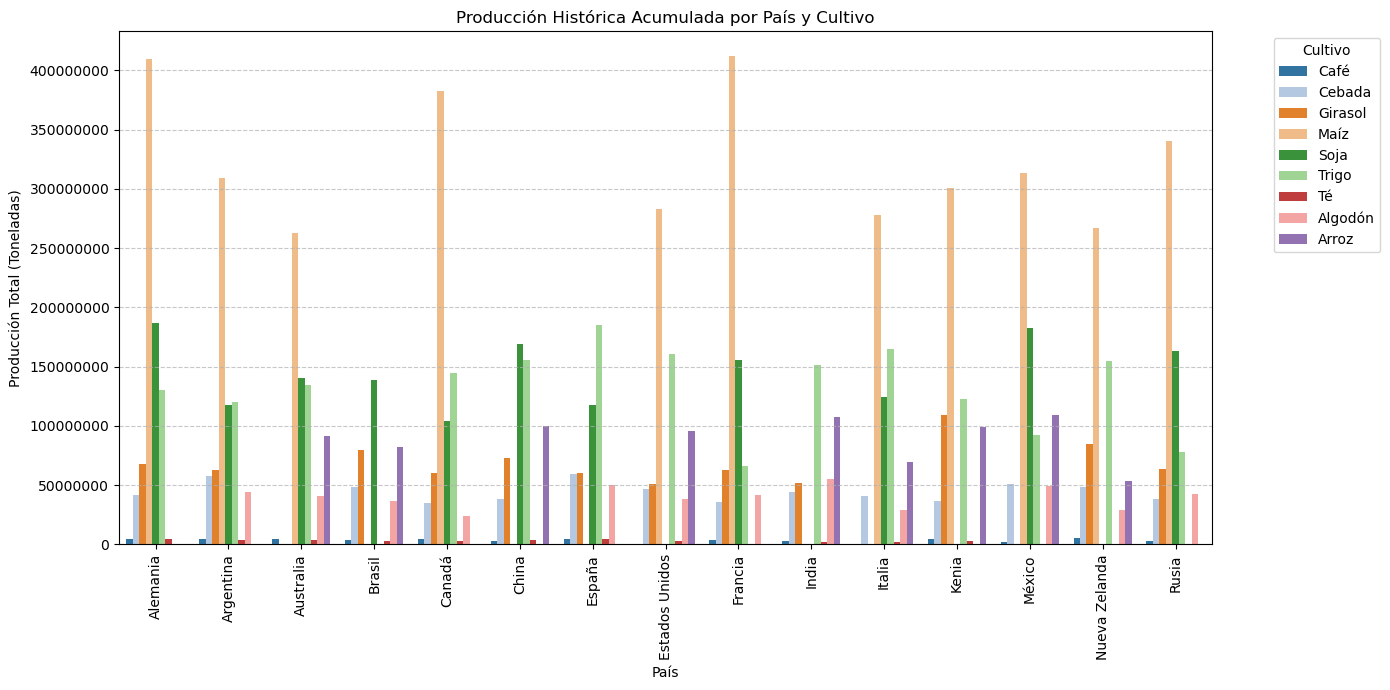

In [17]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

prod_pais_cultivo_sin_cana = prod_pais_cultivo[prod_pais_cultivo['cultivo'] != 'Caña de azúcar']
# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo_sin_cana[prod_pais_cultivo_sin_cana['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

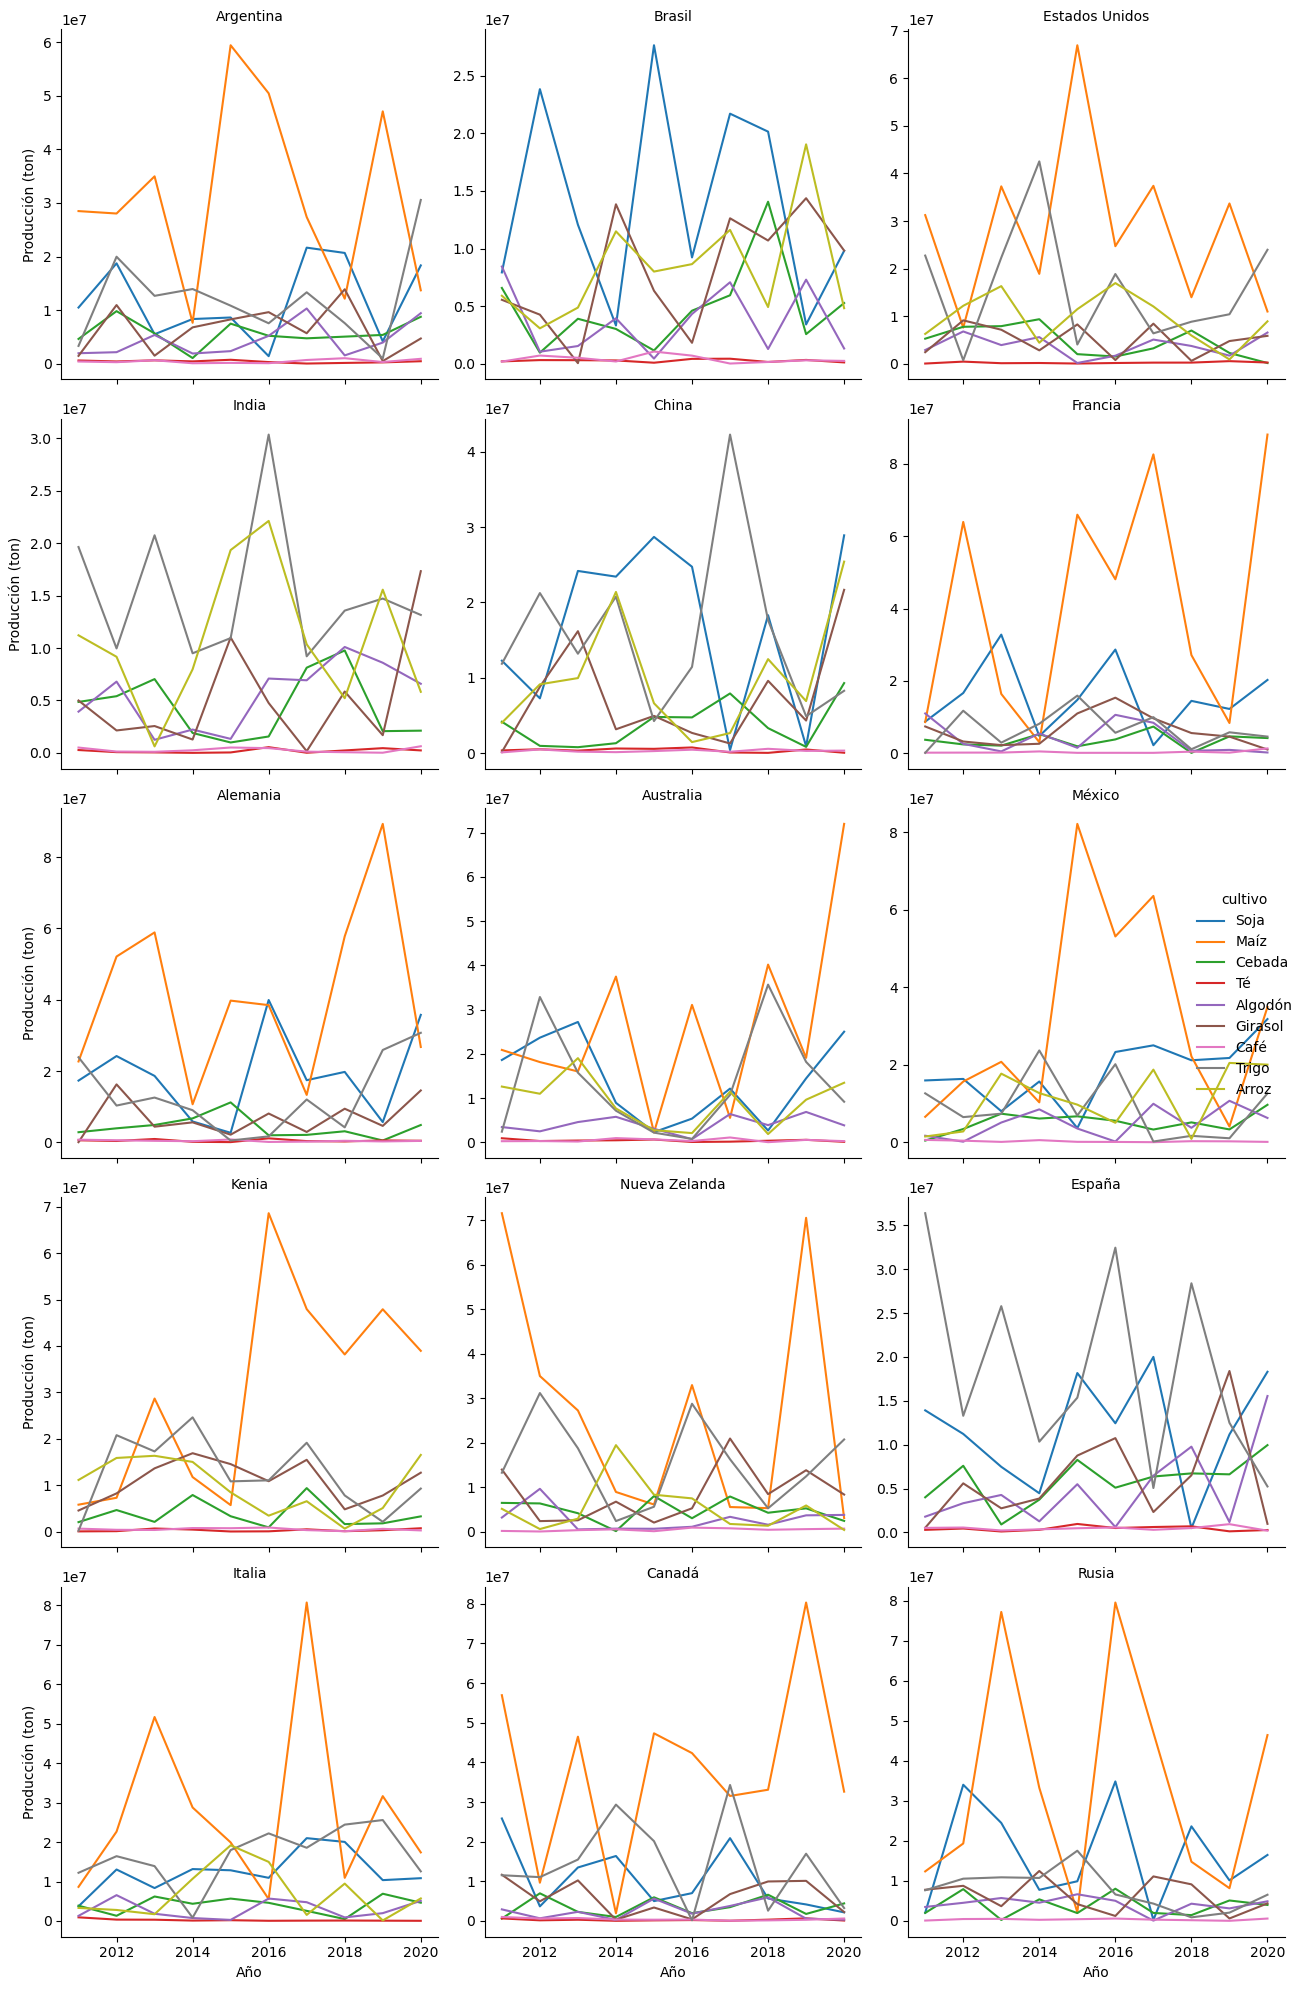

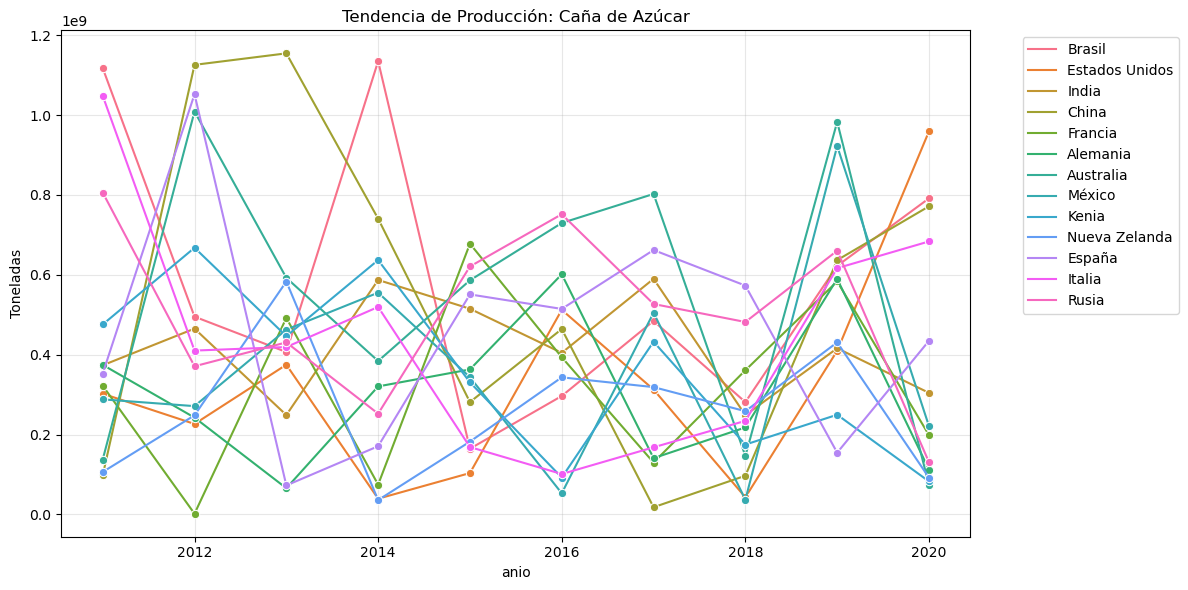

In [18]:
# Gráfico para TODOS los países y cultivos (FacetGrid)
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
g = sns.FacetGrid(df_sin_cana, col="pais", hue="cultivo", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "anio", "produccion_ton")
g.add_legend()
g.set_axis_labels("Año", "Producción (ton)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

# Gráfico específico para CAÑA DE AZÚCAR
df_cana = df_agri[df_agri['cultivo'] == 'Caña de azúcar']
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_cana, x='anio', y='produccion_ton', hue='pais', marker='o')
plt.title('Tendencia de Producción: Caña de Azúcar')
plt.ylabel('Toneladas')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Como se puede observar no existe una tendencia en la produccion, tan solo la produccion que se mantiene estable en el tiempo es el café y el té.

#### 2. Anomalías en series temporales

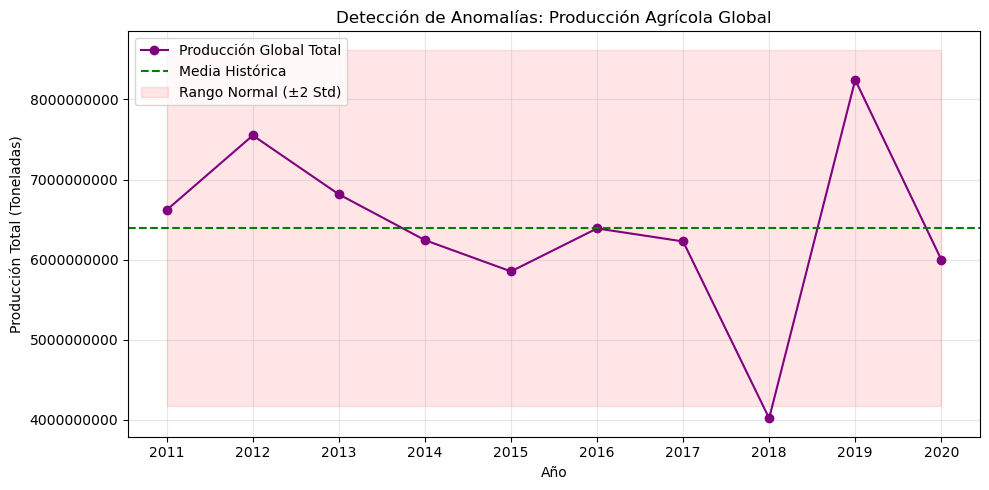

In [19]:
# Agrupamos la producción global total por año
tendencia_global = df_agri.groupby('anio')['produccion_ton'].sum().reset_index()

media_global = tendencia_global['produccion_ton'].mean()
std_global = tendencia_global['produccion_ton'].std()

plt.figure(figsize=(10, 5))
plt.plot(tendencia_global['anio'], tendencia_global['produccion_ton'], marker='o', color='purple', label='Producción Global Total')
plt.axhline(media_global, color='green', linestyle='--', label='Media Histórica')
plt.fill_between(tendencia_global['anio'], media_global - 2*std_global, media_global + 2*std_global, color='red', alpha=0.1, label='Rango Normal (±2 Std)')
plt.title('Detección de Anomalías: Producción Agrícola Global')
plt.xlabel('Año')
plt.ylabel('Producción Total (Toneladas)')
plt.xticks(range(2011, 2021))
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#### 3. Patrones estacionales

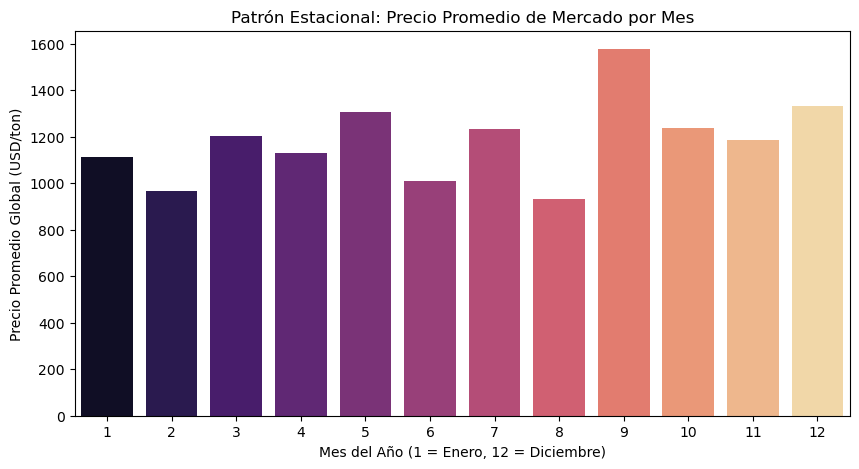

In [20]:
# Cargar el dataset de precios
df_precios = pd.read_csv('datos/precios_mercado.csv')

# Transformar la columna fecha para extraer el "Mes"
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['mes'] = df_precios['fecha'].dt.month

# Agrupar el precio promedio global por mes
estacionalidad_global = df_precios.groupby('mes')['precio_usd_ton'].mean().reset_index()

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')

plt.title('Patrón Estacional: Precio Promedio de Mercado por Mes')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Precio Promedio Global (USD/ton)')
plt.show()

### Geoespacial

#### 1. Clusterización de países por patrones productivos

c:\Users\Ccp0897\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


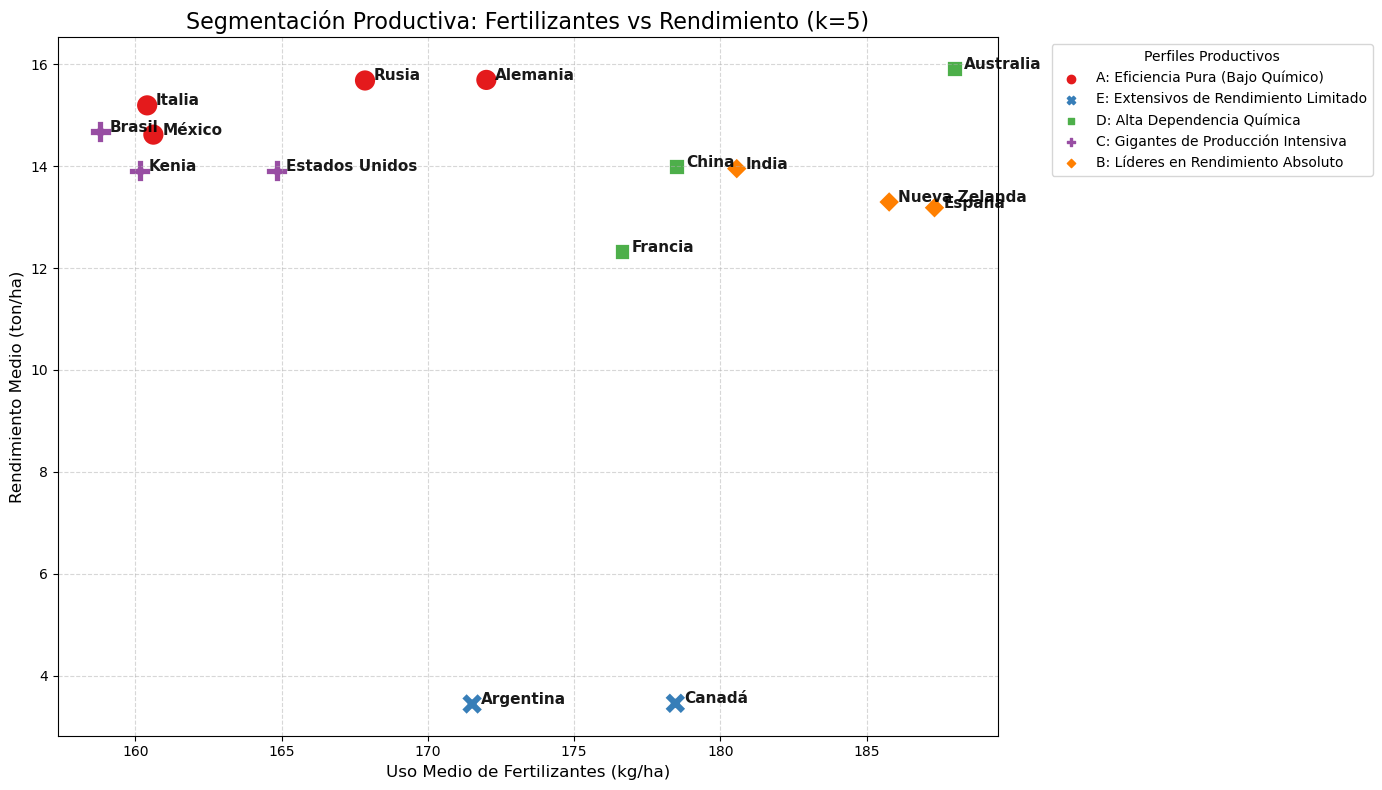

In [21]:
df_ag_pais = df_agri.groupby('pais').agg({
    'produccion_ton': 'mean',
    'rendimiento_ton_ha': 'mean',
    'fertilizantes_kg_ha': 'mean',
    'superficie_hectareas': 'mean'
}).reset_index()

# 3. Machine Learning: Preparar y Escalar (K=5)
features = ['produccion_ton', 'rendimiento_ton_ha', 'fertilizantes_kg_ha', 'superficie_hectareas']
X_scaled = StandardScaler().fit_transform(df_ag_pais[features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_ag_pais['cluster_num'] = kmeans.fit_predict(X_scaled)

# 4. Asignar nombres de negocio a los clústeres (Basados en nuestro análisis)
nombres_clusters = {
    3: 'A: Eficiencia Pura (Bajo Químico)',
    4: 'B: Líderes en Rendimiento Absoluto',
    0: 'C: Gigantes de Producción Intensiva',
    1: 'D: Alta Dependencia Química',
    2: 'E: Extensivos de Rendimiento Limitado'
}
df_ag_pais['Perfil_Productivo'] = df_ag_pais['cluster_num'].map(nombres_clusters)

# 5. Visualización
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_ag_pais, 
    x='fertilizantes_kg_ha', 
    y='rendimiento_ton_ha', 
    hue='Perfil_Productivo', 
    palette='Set1', 
    s=250, 
    style='Perfil_Productivo'
)

# Añadir etiquetas de países
for i in range(df_ag_pais.shape[0]):
    plt.text(df_ag_pais['fertilizantes_kg_ha'][i] + 0.3, # Desplazamiento X
             df_ag_pais['rendimiento_ton_ha'][i], 
             df_ag_pais['pais'][i], fontsize=11, alpha=0.9, fontweight='bold')

plt.title('Segmentación Productiva: Fertilizantes vs Rendimiento (k=5)', fontsize=16)
plt.xlabel('Uso Medio de Fertilizantes (kg/ha)', fontsize=12)
plt.ylabel('Rendimiento Medio (ton/ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Forzar leyenda fuera del gráfico
plt.legend(title="Perfiles Productivos", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

Al evaluar solo las técnicas de cultivo, el algoritmo ha detectado esto:

Clúster A: "Eficiencia Pura" (Brasil, EE.UU., Kenia): Logran muy buenos rendimientos usando la cantidad más baja de fertilizantes de todo el dataset.

Clúster B: "Líderes de Rendimiento" (Alemania, Italia, México, Rusia): Consiguen el rendimiento por hectárea más alto posible, con grandes extensiones de terreno y un uso moderado de químicos.

Clúster C: "Gigantes Intensivos" (Australia, China, Francia): Las mayores medias de producción total, pero a costa de usar dosis muy altas de fertilizantes.

Clúster D: "Dependencia Química" (España, India, Nueva Zelanda): Usan la mayor cantidad de fertilizantes de todo el mundo para mantener sus rendimientos a flote en terrenos más pequeños.

Clúster E: "Extensivos Limitados" (Argentina, Canadá): Rendimientos por hectárea muy bajos a pesar de usar grandes dosis de fertilizante.

#### 2. Comparación eficiencia productiva

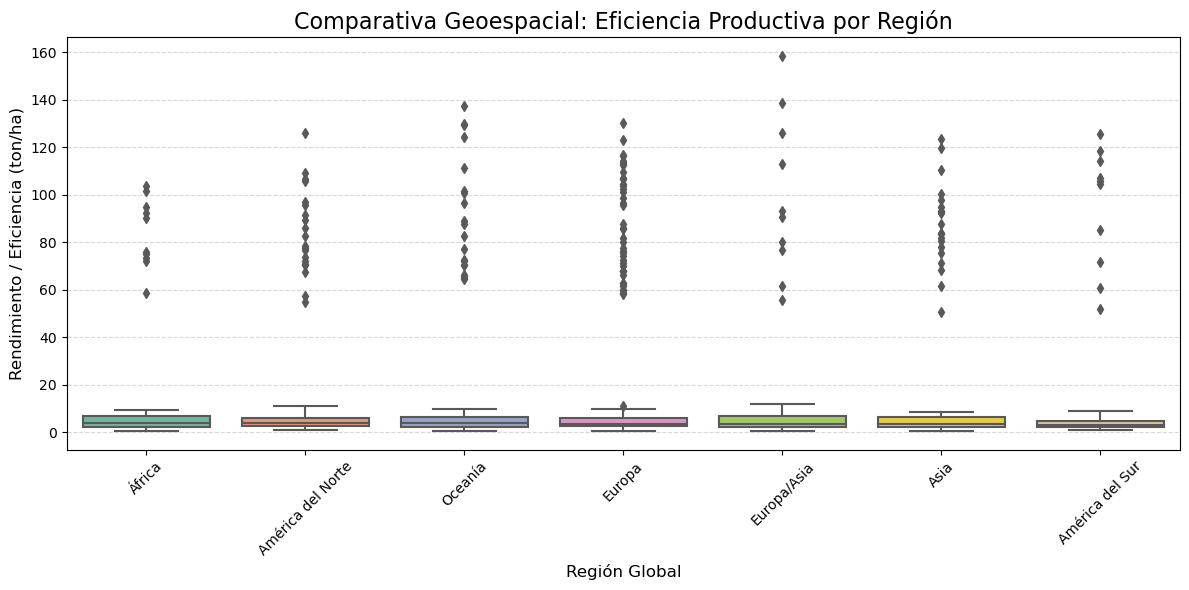

--- Mediana de Rendimiento por Región ---
region
África               3.970
América del Norte    3.675
Oceanía              3.625
Europa               3.540
Europa/Asia          3.425
Asia                 3.285
América del Sur      3.140
Name: rendimiento_ton_ha, dtype: float64


In [22]:
# Calcular el orden: Ordenamos las regiones por su rendimiento mediano
orden_regiones = df_agri.groupby('region')['rendimiento_ton_ha'].median().sort_values(ascending=False).index

# Visualización: Diagrama de Cajas ordenado
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_agri, 
    x='region', 
    y='rendimiento_ton_ha', 
    order=orden_regiones, 
    palette='Set2'
)

plt.title('Comparativa Geoespacial: Eficiencia Productiva por Región', fontsize=16)
plt.xlabel('Región Global', fontsize=12)
plt.ylabel('Rendimiento / Eficiencia (ton/ha)', fontsize=12)
plt.xticks(rotation=45) # Rotamos los textos del eje X para que no se pisen
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Imprimimos los datos exactos por consola para ayudarte a redactar
print("--- Mediana de Rendimiento por Región ---")
print(df_agri.groupby('region')['rendimiento_ton_ha'].median().sort_values(ascending=False))

### Coste ambiental

#### 1. Producción vs Emisiones

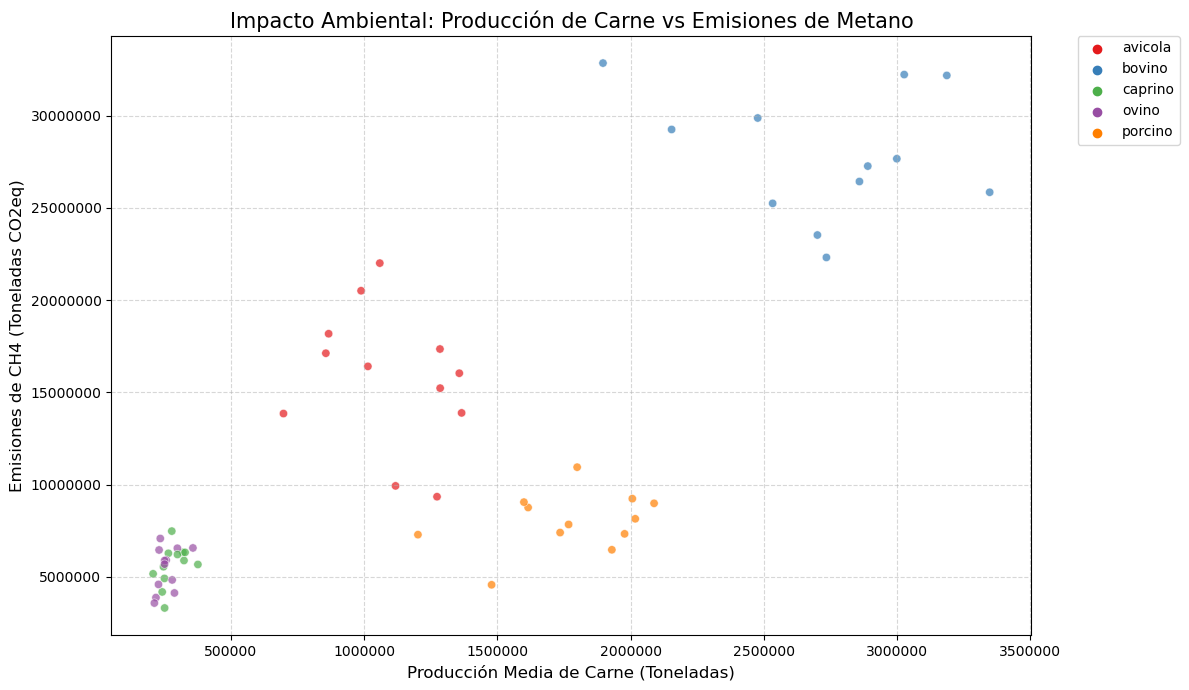

In [23]:
# Agrupar los datos históricos (Promedio por país y tipo de ganado)
ganaderia_agrupada = df_gana.groupby(['pais', 'tipo_ganado']).agg({
    'produccion_carne_ton': 'mean',
    'emisiones_ch4_ton_co2eq': 'mean',
    'cabezas_ganado': 'mean'
}).reset_index()

# Visualización: Gráfico de dispersión (Burbujas)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=ganaderia_agrupada, 
    x='produccion_carne_ton', 
    y='emisiones_ch4_ton_co2eq', 
    hue='tipo_ganado', 
    alpha=0.7, 
    palette='Set1'
)

plt.title('Impacto Ambiental: Producción de Carne vs Emisiones de Metano', fontsize=15)
plt.xlabel('Producción Media de Carne (Toneladas)', fontsize=12)
plt.ylabel('Emisiones de CH4 (Toneladas CO2eq)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Quitar notación científica
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

#### 2. Eficiencia de emisiones

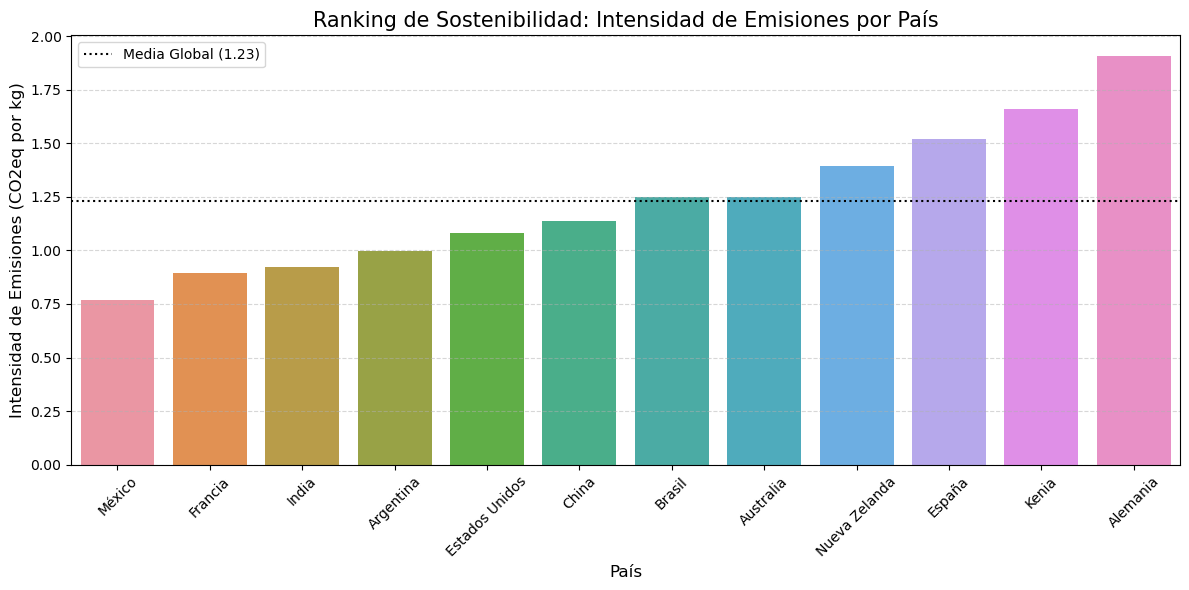

In [24]:
eficiencia_pais = df_gana.groupby('pais')['intensidad_emisiones'].mean().sort_values().reset_index()

# 2. Seleccionar el Top 5 más limpios y el Top 5 más contaminantes
top_limpios = eficiencia_pais.head()
top_contaminantes = eficiencia_pais.tail(5)
ranking_extremos = eficiencia_pais

# 3. Visualización: Gráfico de barras
plt.figure(figsize=(12, 6))

sns.barplot(data=ranking_extremos, x='pais', y='intensidad_emisiones')

plt.title('Ranking de Sostenibilidad: Intensidad de Emisiones por País', fontsize=15)
plt.xlabel('País', fontsize=12)
plt.ylabel('Intensidad de Emisiones (CO2eq por kg)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir una línea para marcar el promedio global
media_global = df_gana['intensidad_emisiones'].mean()
plt.axhline(media_global, color='black', linestyle=':', label=f'Media Global ({media_global:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

### Prospección

#### 1. Productividad

- Agricola

In [25]:
df_ag = pd.read_csv('datos/produccion_agricola.csv')
df_clima = pd.read_csv('datos/condiciones_climaticas_limpios.csv')

In [26]:
df_ag.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [27]:
df_clima.head()

,anio,codigo_iso,dias_con_heladas,eventos_extremos,humedad_relativa_promedio,indice_aridez,meses_estres_hidrico,pais,precipitacion_total,region_nombre,temperatura_maxima,temperatura_minima,temperatura_promedio
0,2011,ARG,19,sin evento,64,17.26,1,Argentina,1050,Pampa Húmeda,22.3,3.6,16.9
1,2011,ARG,48,sin evento,82,8.63,6,Argentina,702,Cuyo,34.6,8.5,22.6
2,2011,ARG,86,sin evento,61,18.37,7,Argentina,635,Patagonia,21.5,2.1,9.6
3,2011,AUS,49,sin evento,59,12.24,0,Australia,1040,Murray-Darling Basin,33.9,18.1,23.6
4,2011,AUS,100,inundacion,82,10.64,1,Australia,912,Queensland Coast,34.5,9.3,23.8


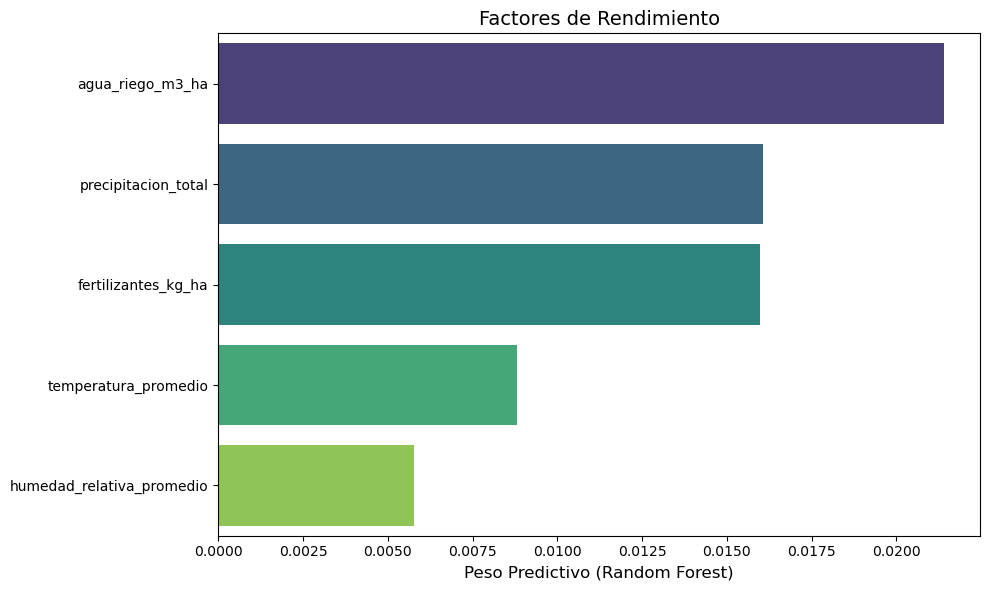

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Unimos por País Y Año simultáneamente
# Usamos left join para no perder ni una sola cosecha
df_modelo = pd.merge(df_ag, df_clima, on=['codigo_iso', 'anio'], how='left')

# Imputación de nulos climáticos (por si algún país/año no tiene datos meteorológicos)
columnas_clima = ['precipitacion_total', 'temperatura_promedio', 'humedad_relativa_promedio']
for col in columnas_clima:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mean())

# Seleccionar variables para el modelo
# Quitamos variables que no son factores predictivos (como país, región, año, producción total...)
df_ml = df_modelo[['cultivo', 'fertilizantes_kg_ha', 'agua_riego_m3_ha', 
                   'precipitacion_total', 'temperatura_promedio', 
                   'humedad_relativa_promedio', 'rendimiento_ton_ha']]

# One-Hot Encoding para el cultivo
df_final = pd.get_dummies(df_ml, columns=['cultivo'])

# Separar X e Y
X = df_final.drop(['rendimiento_ton_ha'], axis=1)
y = df_final['rendimiento_ton_ha']

# Entrenar el Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extraer importancia (limpiando las variables "dummy" de cultivos para el gráfico)
importancia = pd.DataFrame({'Factor': X.columns, 'Importancia': rf.feature_importances_})
importancia = importancia[~importancia['Factor'].str.contains('cultivo_')]
importancia = importancia.sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=importancia, x='Importancia', y='Factor', palette='viridis')
plt.title('Factores de Rendimiento', fontsize=14)
plt.xlabel('Peso Predictivo (Random Forest)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()



In [29]:
df_final

,fertilizantes_kg_ha,agua_riego_m3_ha,precipitacion_total,temperatura_promedio,humedad_relativa_promedio,rendimiento_ton_ha,cultivo_Algodón,cultivo_Arroz,cultivo_Café,cultivo_Caña de azúcar,cultivo_Cebada,cultivo_Girasol,cultivo_Maíz,cultivo_Soja,cultivo_Trigo,cultivo_Té
0,105,4811,1050.000000,16.900000,64.000000,2.22,0,0,0,0,0,0,0,1,0,0
1,105,4811,702.000000,22.600000,82.000000,2.22,0,0,0,0,0,0,0,1,0,0
2,105,4811,635.000000,9.600000,61.000000,2.22,0,0,0,0,0,0,0,1,0,0
3,164,5557,1050.000000,16.900000,64.000000,8.45,0,0,0,0,0,0,1,0,0,0
4,164,5557,702.000000,22.600000,82.000000,8.45,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,69,3711,905.453846,17.802308,60.973077,2.53,1,0,0,0,0,0,0,0,0,0
2476,97,1058,905.453846,17.802308,60.973077,1.84,0,0,1,0,0,0,0,0,0,0
2477,178,9602,905.453846,17.802308,60.973077,2.98,0,0,0,0,1,0,0,0,0,0
2478,61,9741,905.453846,17.802308,60.973077,7.32,0,0,0,0,0,0,1,0,0,0


- Ganadera

In [30]:
df_gana

,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346
4,Argentina,2011,caprino,2045715,345732,454558689,284966,0.139,0.1690
...,...,...,...,...,...,...,...,...,...
595,España,2020,bovino,50472337,2156785,3779283817,10080837,0.200,0.0427
596,España,2020,porcino,13165170,1297936,0,3469971,0.264,0.0986
597,España,2020,avicola,582761175,730468,0,14279694,0.025,0.0013
598,España,2020,ovino,5898700,137149,439518765,3189508,0.541,0.0233


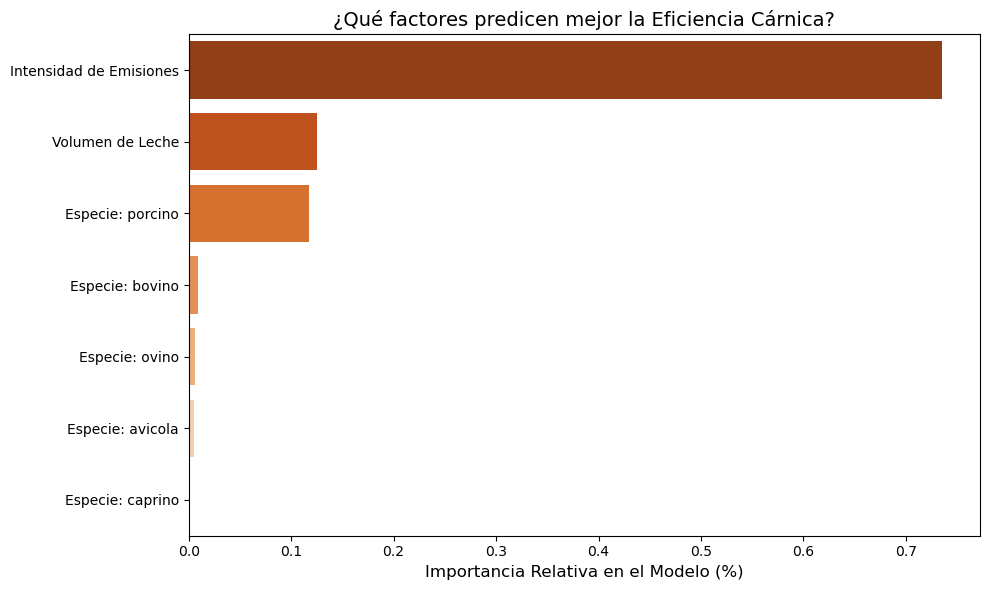

In [31]:

df_gan = pd.read_csv('datos/produccion_ganadera.csv')

# Seleccionamos las variables útiles. 
# EXCLUIMOS 'cabezas_ganado' y 'produccion_carne_ton' porque son la fórmula de 'eficiencia_carne'.
# Incluimos 'produccion_leche_lt' como variable predictora extra (las vacas lecheras producen menos carne).
df_ml = df_gan[['tipo_ganado', 'produccion_leche_lt', 'intensidad_emisiones', 'eficiencia_carne']].dropna()

# FEATURE ENGINEERING
# Convertimos el texto del animal a variables binarias (One-Hot Encoding)
X_gan = pd.get_dummies(df_ml[['tipo_ganado', 'produccion_leche_lt', 'intensidad_emisiones']], columns=['tipo_ganado'])
y_gan = df_ml['eficiencia_carne']

# MACHINE LEARNING (RANDOM FOREST)
rf_gan = RandomForestRegressor(n_estimators=100, random_state=42)
rf_gan.fit(X_gan, y_gan)

# VISUALIZACIÓN DE RESULTADOS
importancia_gan = pd.DataFrame({'Factor': X_gan.columns, 'Importancia': rf_gan.feature_importances_})

# Limpiar los nombres para que el gráfico quede de exposición
importancia_gan['Factor'] = importancia_gan['Factor'].str.replace('tipo_ganado_', 'Especie: ')
importancia_gan['Factor'] = importancia_gan['Factor'].str.replace('produccion_leche_lt', 'Volumen de Leche')
importancia_gan['Factor'] = importancia_gan['Factor'].str.replace('intensidad_emisiones', 'Intensidad de Emisiones')

importancia_gan = importancia_gan.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_gan, x='Importancia', y='Factor', palette='Oranges_r')
plt.title('¿Qué factores predicen mejor la Eficiencia Cárnica?', fontsize=14)
plt.xlabel('Importancia Relativa en el Modelo (%)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

#### 2. Diferencias entre regiones

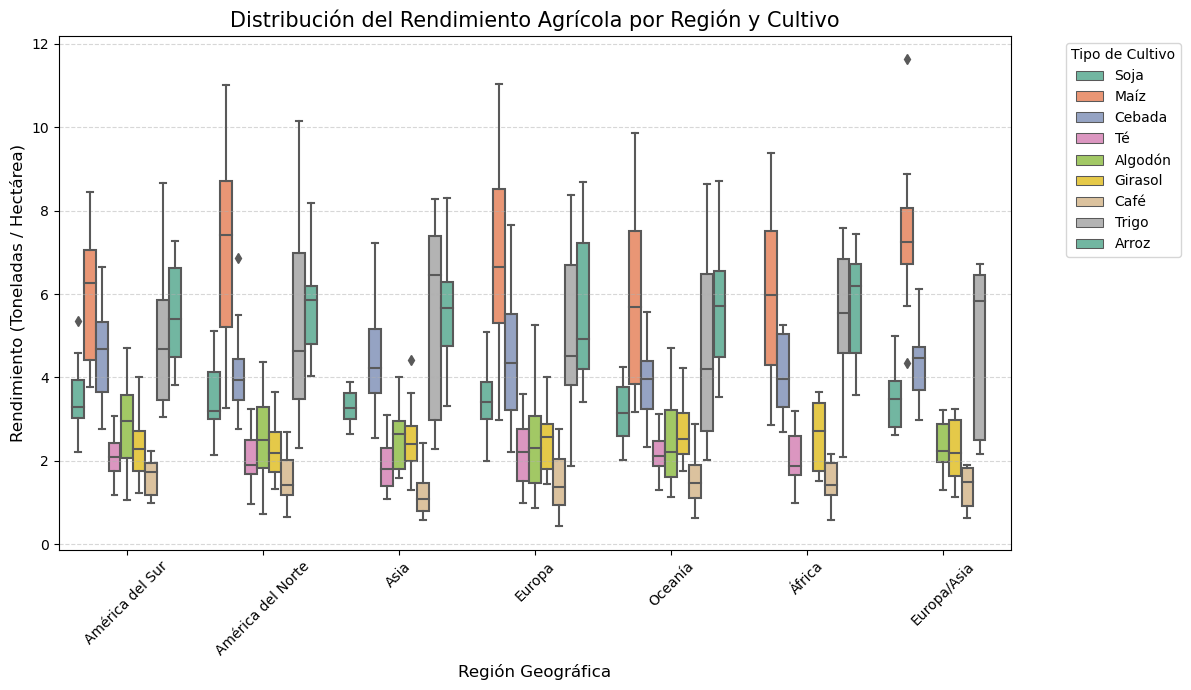

In [32]:
# Nos aseguramos de no tener nulos en las columnas clave
df_region = df_ag.dropna(subset=['region', 'rendimiento_ton_ha', 'cultivo'])

df_region_sin_cana = df_region[df_region['cultivo'] != 'Caña de azúcar']
# Boxplot
plt.figure(figsize=(12, 7))

# Creamos el boxplot
sns.boxplot(
    data=df_region_sin_cana, 
    x='region', 
    y='rendimiento_ton_ha', 
    hue='cultivo', # Separamos por cultivo porque un tomate no rinde lo mismo que el trigo
    palette='Set2'
)

# Ajustes de diseño
plt.title('Distribución del Rendimiento Agrícola por Región y Cultivo', fontsize=15)
plt.xlabel('Región Geográfica', fontsize=12)
plt.ylabel('Rendimiento (Toneladas / Hectárea)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Tipo de Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

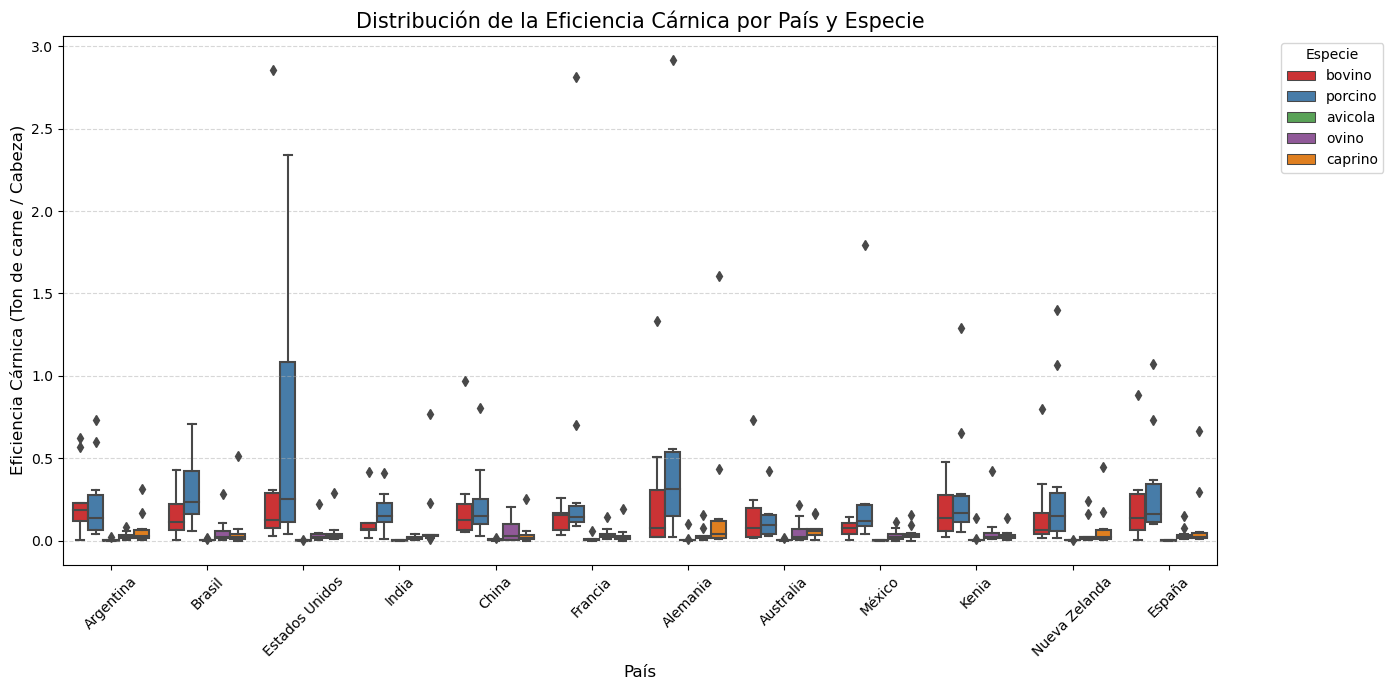

In [33]:
# Nos aseguramos de no tener nulos en las columnas clave
df_pais_gan = df_gan.dropna(subset=['pais', 'eficiencia_carne', 'tipo_ganado'])

# Boxplot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_pais_gan, 
    x='pais', 
    y='eficiencia_carne', 
    hue='tipo_ganado',
    palette='Set1'
)

plt.title('Distribución de la Eficiencia Cárnica por País y Especie', fontsize=15)
plt.xlabel('País', fontsize=12)
plt.ylabel('Eficiencia Cárnica (Ton de carne / Cabeza)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Sostenibilidad

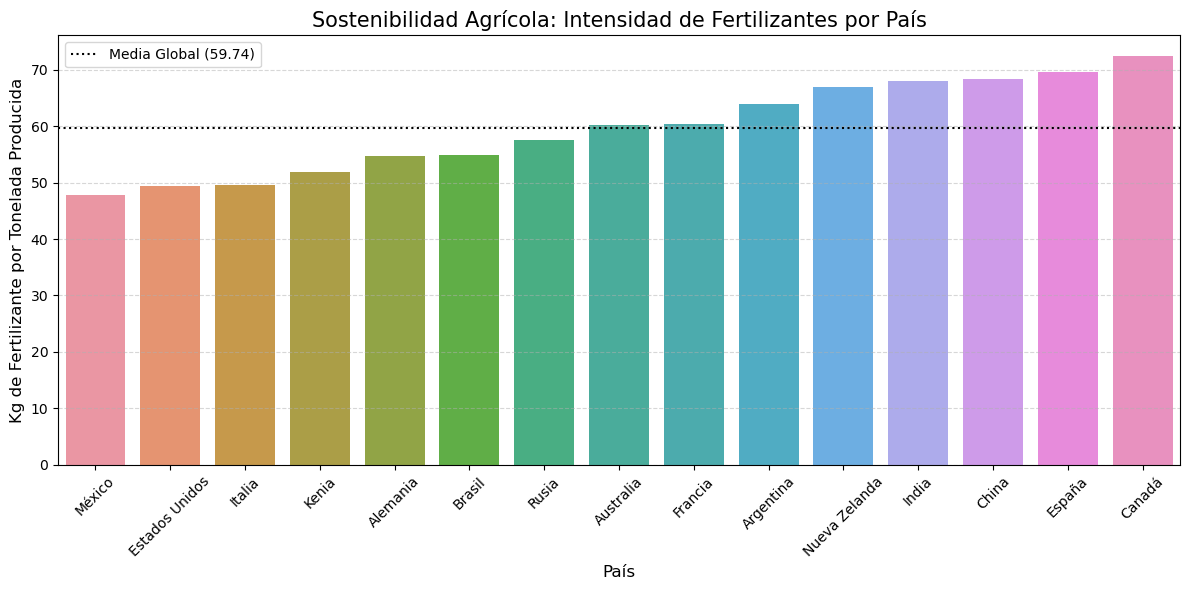

In [34]:

# Calculamos la intensidad de emisiones del fertilizante
df_ag['intensidad_fertilizante'] = df_ag['fertilizantes_kg_ha'] / df_ag['rendimiento_ton_ha']

# Agrupamos por país
eficiencia_ag = df_ag.groupby('pais')['intensidad_fertilizante'].mean().sort_values().reset_index()

ranking_ag_extremos = eficiencia_ag

# Visualización
plt.figure(figsize=(12, 6))

sns.barplot(data=ranking_ag_extremos, x='pais', y='intensidad_fertilizante')

plt.title('Sostenibilidad Agrícola: Intensidad de Fertilizantes por País', fontsize=15)
plt.xlabel('País', fontsize=12)
plt.ylabel('Kg de Fertilizante por Tonelada Producida', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Línea de media global para contexto
media_global_ag = eficiencia_ag['intensidad_fertilizante'].mean()
plt.axhline(media_global_ag, color='black', linestyle=':', label=f'Media Global ({media_global_ag:.2f})')

plt.legend()
plt.tight_layout()
plt.show()

#### 3. Riesgo climático

- Cultivos vulnerables

In [35]:
#Cruzar datos de clima y agricultura
df_clima_prod = pd.merge(df_ag, df_clima, on=['anio', 'pais', 'codigo_iso'], how='inner')
df_clima_prod

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,...,dias_con_heladas,eventos_extremos,humedad_relativa_promedio,indice_aridez,meses_estres_hidrico,precipitacion_total,region_nombre,temperatura_maxima,temperatura_minima,temperatura_promedio
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,...,19,sin evento,64,17.26,1,1050,Pampa Húmeda,22.3,3.6,16.9
1,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,...,48,sin evento,82,8.63,6,702,Cuyo,34.6,8.5,22.6
2,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,...,86,sin evento,61,18.37,7,635,Patagonia,21.5,2.1,9.6
3,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,...,19,sin evento,64,17.26,1,1050,Pampa Húmeda,22.3,3.6,16.9
4,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,...,48,sin evento,82,8.63,6,702,Cuyo,34.6,8.5,22.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,Kenia,KEN,África,Arroz,2020,2415943,6.83,16508239,70,6500,...,111,sin evento,64,11.84,0,938,Región Principal,35.7,9.1,22.0
2076,Kenia,KEN,África,Maíz,2020,5214983,7.47,38945261,208,1669,...,111,sin evento,64,11.84,0,938,Región Principal,35.7,9.1,22.0
2077,Kenia,KEN,África,Té,2020,262109,2.67,700065,85,6487,...,111,sin evento,64,11.84,0,938,Región Principal,35.7,9.1,22.0
2078,Kenia,KEN,África,Girasol,2020,3483346,3.64,12677903,229,4437,...,111,sin evento,64,11.84,0,938,Región Principal,35.7,9.1,22.0


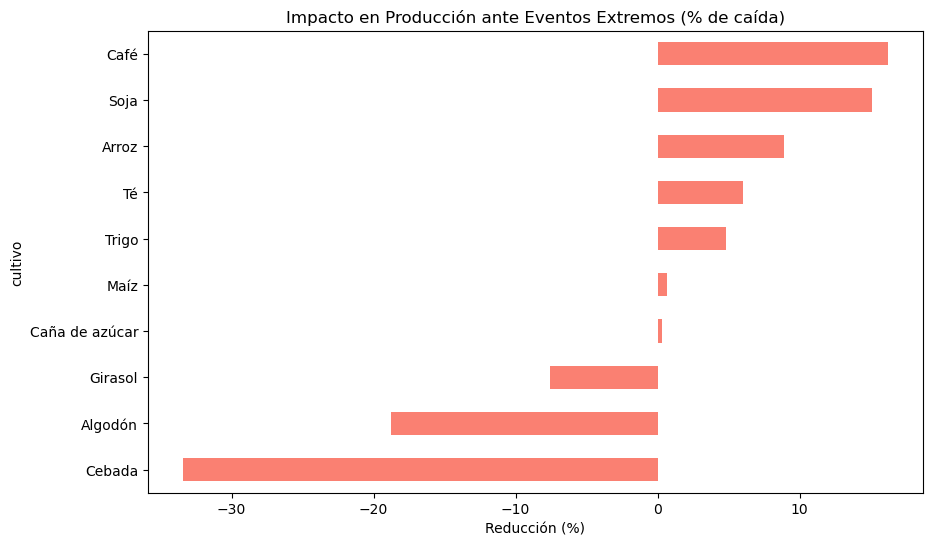

In [36]:
# Calcular impacto de eventos extremos
df_clima_prod['es_extremo'] = df_clima_prod['eventos_extremos'] != 'sin evento'
impacto = df_clima_prod.groupby(['cultivo', 'es_extremo'])['produccion_ton'].mean().unstack()
impacto['drop_porcentual'] = (impacto[False] - impacto[True]) / impacto[False] * 100

plt.figure(figsize=(10, 6))
impacto['drop_porcentual'].sort_values().plot(kind='barh', color='salmon')
plt.title('Impacto en Producción ante Eventos Extremos (% de caída)')
plt.xlabel('Reducción (%)')
plt.show()



- Pérdidas por sequía

In [45]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Unir producción y clima
clima_pais = df_clima.groupby(['anio', 'pais', 'codigo_iso']).agg({
    'humedad_relativa_promedio': 'mean',
    'precipitacion_total': 'mean',
    'indice_aridez': 'mean',
    'meses_estres_hidrico': 'mean',
    'temperatura_maxima': 'mean'
}).reset_index()

df_merged = pd.merge(df_ag, clima_pais, on=['anio', 'pais', 'codigo_iso'])


In [47]:
# Definir las variables que predicen la sequía (X) y lo que queremos predecir (y)
variables_predictoras = ['humedad_relativa_promedio','precipitacion_total', 'indice_aridez', 'meses_estres_hidrico', 'temperatura_maxima']
objetivo = 'rendimiento_ton_ha'

# Entrenar el modelo de predicción
cultivos = df_merged['cultivo'].unique()
resultados = []
importancias_list = []

for cultivo in cultivos:
    # Filtrar solo el cultivo actual
    df_crop = df_merged[df_merged['cultivo'] == cultivo].dropna(subset=variables_predictoras + [objetivo])
    
    # Evitar entrenar si hay muy pocos datos para ese cultivo
    if len(df_crop) < 30: 
        continue
        
    X = df_crop[variables_predictoras]
    y = df_crop[objetivo]
    
    # Entrenar Random Forest
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo = RandomForestRegressor(n_estimators=100, random_state=42)
    modelo.fit(X_train, y_train)
    
    # Mostrar qué variables fueron más importantes para ESTE cultivo
    importancia = modelo.feature_importances_
    top_var_index = importancia.argmax()
    variable_top = variables_predictoras[top_var_index]
    
    resultados.append({
        'Cultivo': cultivo,
        'Principal_Predictor_Sequia': variable_top
    })

    # Almacenar las importancias para el gráfico
    for i, var in enumerate(variables_predictoras):
        importancias_list.append({
            'Cultivo': cultivo,
            'Variable': var,
            'Importancia': importancia[i]
        })

print(pd.DataFrame(resultados))

          Cultivo Principal_Predictor_Sequia
0            Soja  humedad_relativa_promedio
1            Maíz         temperatura_maxima
2          Cebada  humedad_relativa_promedio
3              Té         temperatura_maxima
4         Algodón       meses_estres_hidrico
5         Girasol         temperatura_maxima
6            Café         temperatura_maxima
7           Trigo              indice_aridez
8           Arroz       meses_estres_hidrico
9  Caña de azúcar        precipitacion_total


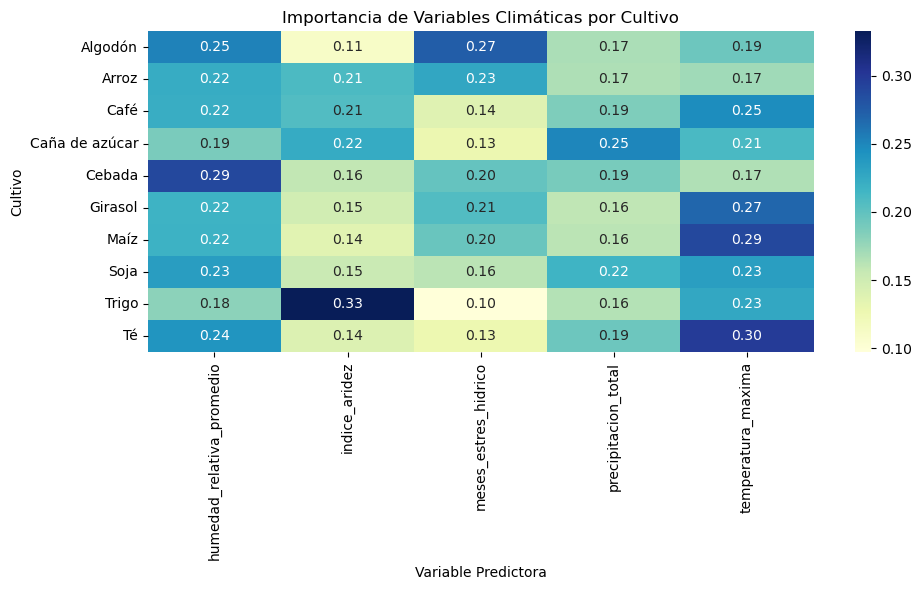

In [49]:
df_importancias = pd.DataFrame(importancias_list)
# Gráfico 1: Importancia de variables por cultivo (Heatmap)
importancias_pivot = df_importancias.pivot(index='Cultivo', columns='Variable', values='Importancia')

plt.figure(figsize=(10, 6))
sns.heatmap(importancias_pivot, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Importancia de Variables Climáticas por Cultivo')
plt.ylabel('Cultivo')
plt.xlabel('Variable Predictora')
plt.tight_layout()